<a href="https://colab.research.google.com/gist/yumimint/c5c0a7724f4f38517ac5ffc86e129f4e/picloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install bitstring

from bitstring import BitStream
from PIL import Image
import numpy as np
import requests
from collections import deque, namedtuple


In [34]:
req = requests.get("https://github.com/yumimint/misc/raw/924af7807aebdb00320c6da32c857990b0610ab2/sample.pic")


In [38]:
def ldecode(bs: BitStream) -> int:
    bits = 1
    # 0が出るまで1をカウントする
    while bs.read("bool"):
        bits += 1

    # 指定したビット数分を整数として読み込む
    x = bs.read(f"uint:{bits}")
    x += (1 << bits) - 1
    return x


def read_until(bs: BitStream, term: bytes):
    buf = b''
    while True:
        b = bs.read("bytes:1")
        if b == term:
            break
        buf += b
    return buf


def read_pic_header(bs: BitStream):
    # 1. Magicの確認
    if bs.read("bytes:3") != b"PIC":
        raise ValueError("Magic not match.")

    # # 2. コメントセクション (0x1aまで)
    comment = read_until(bs, b"\x1a")

    # # 3. ダミー/真の終端 (0x00まで)
    dummy = read_until(bs, b"\x00")

    res, mode, bpp, width, height = bs.readlist("2*uint:8, 3*uint:16")

    HD = namedtuple(
        "PIC_Header", "comment dummy reserve mode bpp width height")
    return HD(comment, dummy, res, mode, bpp, width, height)


class ColorCache:
    class Node:
        color = 0
        next = 0
        prev = 0

    def __init__(self):
        self.table = [ self.Node() for i in range(128) ]
        self.color_p = 0  # 最新色を指す
        self.clear()

    def clear(self):
        """色キャッシュの初期化"""
        for i in range(128):
            self.table[i].color = 0
            self.table[i].prev = i + 1
            self.table[i].next = i - 1
        self.table[127].prev = 0
        self.table[0].next = 127
        self.color_p = 0

    def get(self, idx):
        """キャッシュから色を取り出しその色が最新になるように更新する"""
        table = self.table
        p = table[idx]
        if self.color_p != idx:
		    # まず位置idxをキャッシュから切り離す
            table[p.prev].next = p.next
            table[p.next].prev = p.prev
            # 最新色の次にidxを新たにセット
            table[table[self.color_p].prev].next = idx
            p.prev = table[self.color_p].prev
            table[self.color_p].prev = idx
            p.next = self.color_p
            # 最新色位置を更新
            self.color_p = idx
        return p.color

    def put(self, color):
        """新しい色をキャッシュに登録"""
        self.color_p = self.table[self.color_p].prev
        self.table[self.color_p].color = color
        return color


def decode_pic(f):
    bs = BitStream(f)

    hd = read_pic_header(bs)
    if hd.bpp != 15:
        return

    cache = ColorCache()
    shape = (hd.height, hd.width)
    pixel = np.zeros(shape, dtype=np.uint16)
    flag = np.zeros(shape, dtype=bool)

    i = 0
    color = 0  # 始まりの色は0
    npixels = hd.width * hd.height
    while i < npixels:
        for i in range(i, min(npixels, i + ldecode(bs))):
            if flag.flat[i]:
                color = pixel.flat[i]
            pixel.flat[i] = color
        i += 1
        if i >= npixels:
            break

        if bs.read("bool"):
            color = cache.get(bs.read("uint:7"))
        else:
            color = cache.put(bs.read(f"uint:{hd.bpp}"))
        pixel.flat[i] = color

        if bs.read("bool"):
            chain(bs, pixel, flag, i)

    return pixel


def chain(bs: BitStream, pix: np.ndarray, flg: np.ndarray, i: int):
    color = pix.flat[i]
    width = pix.shape[1]
    while True:
        lr = bs.read("uint:2")
        if lr == 0:
            if not bs.read("bool"):
                break
            else:
                d = 2 if bs.read("bool") else -2
        elif lr == 1:
            d = -1
        elif lr == 2:
            d = 0
        elif lr == 3:
            d = 1
        i += width + d
        pix.flat[i] = color
        flg.flat[i] = True


def x68_15_to_rgb(color):
    # 1. 各色を5ビットで抽出 (0-31)
    g_5 = (color >> 10) & 0x1F
    r_5 = (color >> 5) & 0x1F
    b_5 = color & 0x1F

    # 2. スケーリング (ビットをずらして結合)
    # 5bitを3bit左シフトし、空いた下位3bitに上位3bitをコピーする
    # 例: 11111 -> 11111000 + 00000111 = 11111111 (255)
    r_8 = (r_5 << 3) | (r_5 >> 2)
    g_8 = (g_5 << 3) | (g_5 >> 2)
    b_8 = (b_5 << 3) | (b_5 >> 2)

    # 3. 配列の結合と画像化
    rgb_array = np.dstack((r_8, g_8, b_8)).astype(np.uint8)

    return Image.fromarray(rgb_array)

In [36]:
read_pic_header(BitStream(req.content))

PIC_Header(comment=b'', dummy=b'', reserve=0, mode=0, bpp=15, width=512, height=512)

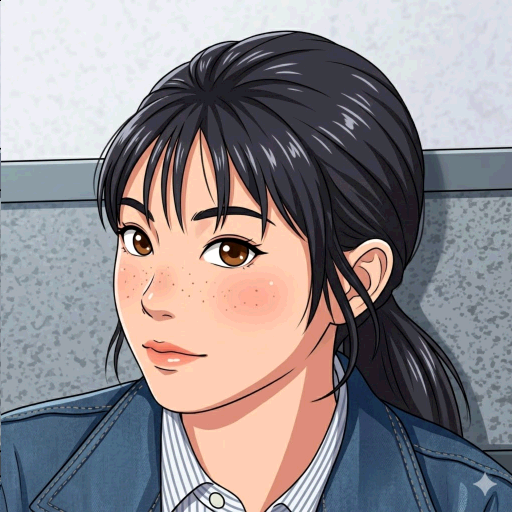

In [39]:
im = decode_pic(BitStream(req.content))
x68_15_to_rgb(im)
